Đang sử dụng device: cuda


C:\Users\luan0\AppData\Local\Temp\ipykernel_12032\344355077.py:60: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(model_path, map_location=DEVICE)


[INFO] Fruit_Cracking - Score: 0.9967

Đã lưu kết quả tại: E:\nckh_cachua\results\Fruit_Cracking_6_jpg.rf.5c5ec89fe4635bc190cb1509ab98e89c.jpg


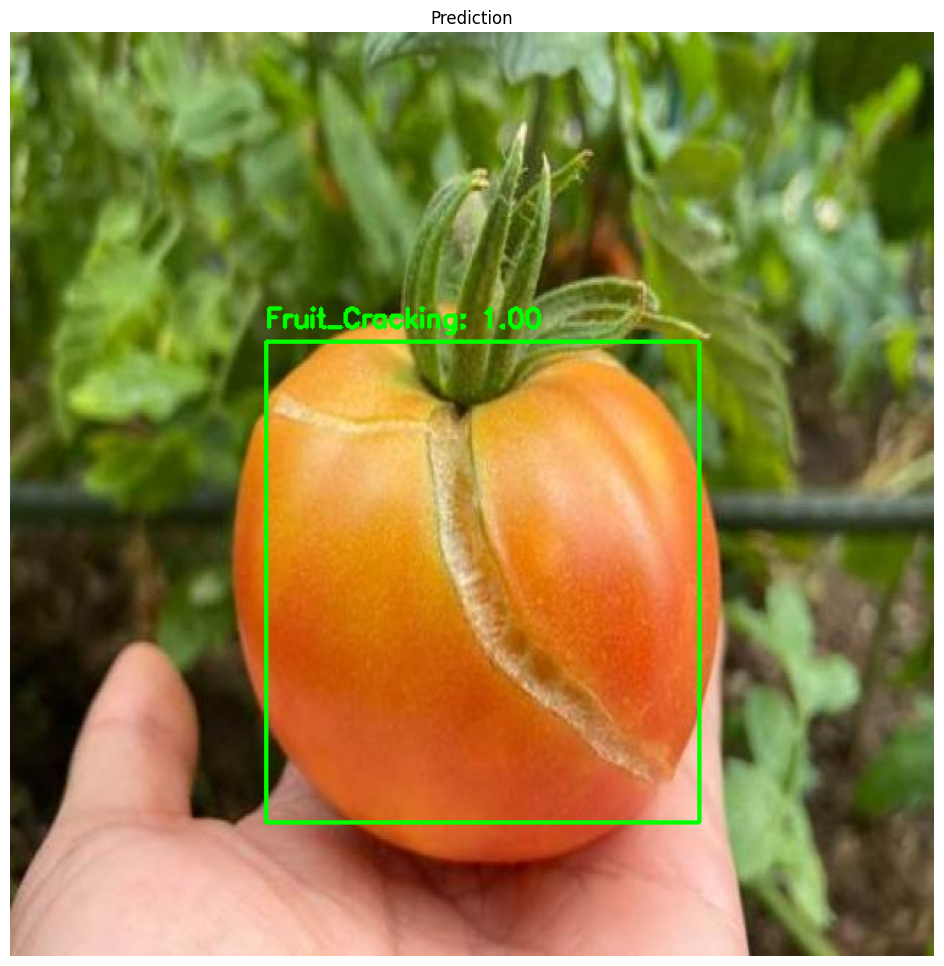

In [1]:
import os
import cv2
import torch
import numpy as np
import torchvision
from torchvision.models.detection import fasterrcnn_mobilenet_v3_large_fpn
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor
import albumentations as A
from albumentations.pytorch import ToTensorV2
import matplotlib.pyplot as plt

# CẤU HÌNH  
MODEL_PATH = r"E:\nckh_cachua\checkpoints\best_model.pth"
IMAGE_PATH = r"E:\nckh_cachua\data\test\Fruit_Cracking_6_jpg.rf.5c5ec89fe4635bc190cb1509ab98e89c.jpg"

SAVE_DIR = r"E:\nckh_cachua\results"
os.makedirs(SAVE_DIR, exist_ok=True)

CONFIDENCE_THRESHOLD = 0.5
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# =========================
# DANH SÁCH CLASS
# =========================
CLASSES = [
    'background',
    'Healthy_Tomato',
    'Blossom_End_Rot',
    'Late_Blight',
    'Mold',
    'Anthracnose',
    'Fruit_Cracking',
    'Catfaced',
    'Spotted_Wilt_Virus'
]

# TRANSFORM TEST
def get_test_transform():
    return A.Compose([
        A.Resize(640, 640),
        ToTensorV2()
    ])

# LOAD MODEL
def get_model(num_classes):
    model = fasterrcnn_mobilenet_v3_large_fpn(weights=None)

    in_features = model.roi_heads.box_predictor.cls_score.in_features

    model.roi_heads.box_predictor = FastRCNNPredictor(
        in_features,
        num_classes
    )

    return model

def load_model(model_path):
    model = get_model(len(CLASSES))

    checkpoint = torch.load(model_path, map_location=DEVICE)

    # Nếu save full checkpoint
    if isinstance(checkpoint, dict) and 'model_state_dict' in checkpoint:
        model.load_state_dict(checkpoint['model_state_dict'])
    else:
        # Nếu save trực tiếp state_dict
        model.load_state_dict(checkpoint)

    model.to(DEVICE)
    model.eval()

    return model

# PREDICT 
def predict_image(model, image_path):

    image_bgr = cv2.imread(image_path)

    if image_bgr is None:
        raise ValueError(f"Không đọc được ảnh: {image_path}")

    original_image = image_bgr.copy()

    image_rgb = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)

    transform = get_test_transform()

    transformed = transform(image=image_rgb)

    image_tensor = transformed['image'].float() / 255.0

    image_tensor = image_tensor.to(DEVICE)

    with torch.no_grad():
        prediction = model([image_tensor])[0]

    boxes = prediction['boxes'].cpu().numpy()
    labels = prediction['labels'].cpu().numpy()
    scores = prediction['scores'].cpu().numpy()

    for box, label, score in zip(boxes, labels, scores):

        if score < CONFIDENCE_THRESHOLD:
            continue

        xmin, ymin, xmax, ymax = map(int, box)

        class_name = CLASSES[label]

        # Vẽ bbox
        cv2.rectangle(
            original_image,
            (xmin, ymin),
            (xmax, ymax),
            (0, 255, 0),
            2
        )

        text = f"{class_name}: {score:.2f}"

        cv2.putText(
            original_image,
            text,
            (xmin, ymin - 10),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.6,
            (0, 255, 0),
            2
        )

        print(f"[INFO] {class_name} - Score: {score:.4f}")

    return original_image

# MAIN

# MAIN
if __name__ == "__main__":

    print(f"Đang sử dụng device: {DEVICE}")

    # Load model
    model = load_model(MODEL_PATH)

    # Predict ảnh
    result_image = predict_image(model, IMAGE_PATH)

    # Tạo đường dẫn lưu
    save_path = os.path.join(
        SAVE_DIR,
        os.path.basename(IMAGE_PATH)
    )

    # Lưu ảnh
    cv2.imwrite(save_path, result_image)

    print(f"\nĐã lưu kết quả tại: {save_path}")

    # Hiển thị bằng matplotlib
    result_rgb = cv2.cvtColor(result_image, cv2.COLOR_BGR2RGB)

    plt.figure(figsize=(12, 12))
    plt.imshow(result_rgb)
    plt.title("Prediction")
    plt.axis("off")
    plt.show()

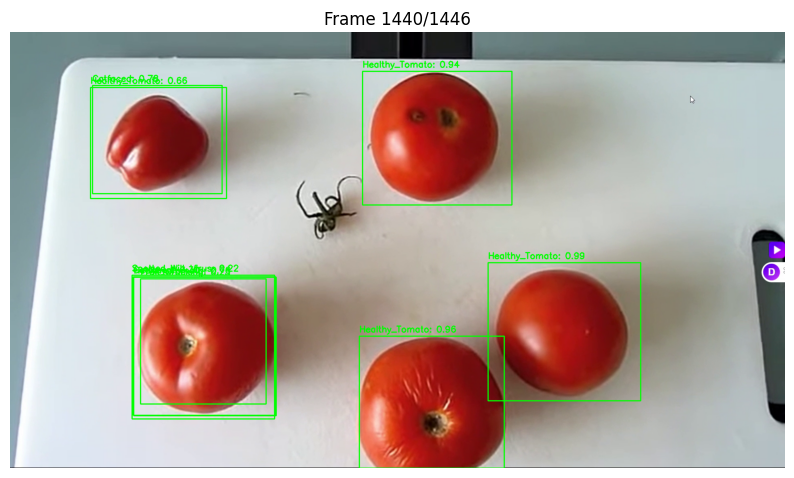

Processed: 1440/1446

Hoàn tất!

Saved video: E:\nckh_cachua\result_detect.mp4


In [2]:
import os
import cv2
import torch
import matplotlib.pyplot as plt

from IPython.display import clear_output

import albumentations as A
from albumentations.pytorch import ToTensorV2

from torchvision.models.detection import fasterrcnn_mobilenet_v3_large_fpn
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor

# =========================
# CONFIG
# =========================
MODEL_PATH = r"E:\nckh_cachua\checkpoints\best_model.pth"

VIDEO_PATH = r"E:\nckh_cachua\demo.mp4"

# KHÔNG ĐƯỢC TRÙNG INPUT VIDEO
OUTPUT_VIDEO = r"E:\nckh_cachua\result_detect.mp4"

CONFIDENCE_THRESHOLD = 0.2

DEVICE = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

# =========================
# CLASSES
# =========================
CLASSES = [
    'background',
    'Healthy_Tomato',
    'Blossom_End_Rot',
    'Late_Blight',
    'Mold',
    'Anthracnose',
    'Fruit_Cracking',
    'Catfaced',
    'Spotted_Wilt_Virus'
]

# =========================
# TRANSFORM
# =========================
transform = A.Compose([
    A.Resize(320, 320),
    ToTensorV2()
])

# =========================
# MODEL
# =========================
def get_model(num_classes):

    model = fasterrcnn_mobilenet_v3_large_fpn(
        weights=None
    )

    in_features = model.roi_heads.box_predictor.cls_score.in_features

    model.roi_heads.box_predictor = FastRCNNPredictor(
        in_features,
        num_classes
    )

    return model


def load_model():

    model = get_model(len(CLASSES))

    checkpoint = torch.load(
        MODEL_PATH,
        map_location=DEVICE
    )

    if (
        isinstance(checkpoint, dict)
        and 'model_state_dict' in checkpoint
    ):
        model.load_state_dict(
            checkpoint['model_state_dict']
        )
    else:
        model.load_state_dict(checkpoint)

    model.to(DEVICE)

    model.eval()

    return model

# =========================
# PREDICT FRAME
# =========================
def predict_frame(model, frame):

    original_h, original_w = frame.shape[:2]

    image_rgb = cv2.cvtColor(
        frame,
        cv2.COLOR_BGR2RGB
    )

    transformed = transform(image=image_rgb)

    image_tensor = (
        transformed['image']
        .float()
        / 255.0
    )

    image_tensor = image_tensor.to(DEVICE)

    with torch.no_grad():

        prediction = model([image_tensor])[0]

    boxes = prediction['boxes'].cpu().numpy()

    labels = prediction['labels'].cpu().numpy()

    scores = prediction['scores'].cpu().numpy()

    scale_x = original_w / 320
    scale_y = original_h / 320

    for box, label, score in zip(
        boxes,
        labels,
        scores
    ):

        if score < CONFIDENCE_THRESHOLD:
            continue

        xmin, ymin, xmax, ymax = box

        xmin = int(xmin * scale_x)
        xmax = int(xmax * scale_x)

        ymin = int(ymin * scale_y)
        ymax = int(ymax * scale_y)

        class_name = CLASSES[label]

        # DRAW BOX
        cv2.rectangle(
            frame,
            (xmin, ymin),
            (xmax, ymax),
            (0, 255, 0),
            2
        )

        # TEXT
        text = f"{class_name}: {score:.2f}"

        cv2.putText(
            frame,
            text,
            (xmin, ymin - 10),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.7,
            (0, 255, 0),
            2
        )

    return frame

# =========================
# MAIN
# =========================
if __name__ == "__main__":

    print(f"Using device: {DEVICE}")

    # LOAD MODEL
    model = load_model()

    # LOAD VIDEO
    cap = cv2.VideoCapture(VIDEO_PATH)

    if not cap.isOpened():
        raise ValueError(
            f"Không mở được video: {VIDEO_PATH}"
        )

    width = int(
        cap.get(cv2.CAP_PROP_FRAME_WIDTH)
    )

    height = int(
        cap.get(cv2.CAP_PROP_FRAME_HEIGHT)
    )

    total_frames = int(
        cap.get(cv2.CAP_PROP_FRAME_COUNT)
    )

    fps = cap.get(cv2.CAP_PROP_FPS)

    if fps <= 0:
        fps = 30

    print(f"Width : {width}")
    print(f"Height: {height}")
    print(f"FPS   : {fps}")
    print(f"Frames: {total_frames}")

    # =========================
    # VIDEO WRITER
    # =========================
    fourcc = cv2.VideoWriter_fourcc(*'mp4v')

    out = cv2.VideoWriter(
        OUTPUT_VIDEO,
        fourcc,
        fps,
        (width, height)
    )

    frame_count = 0

    print("\nĐang xử lý video...\n")

    while True:

        ret, frame = cap.read()

        if not ret:
            break

        frame_count += 1

        result_frame = frame.copy()

        # DETECT MỖI 2 FRAME
        if frame_count % 2 == 0:

            result_frame = predict_frame(
                model,
                result_frame
            )

        # SAVE VIDEO
        out.write(result_frame)

        # HIỂN THỊ REALTIME TRONG NOTEBOOK
        if frame_count % 20 == 0:

            clear_output(wait=True)

            rgb_frame = cv2.cvtColor(
                result_frame,
                cv2.COLOR_BGR2RGB
            )

            plt.figure(figsize=(10, 6))

            plt.imshow(rgb_frame)

            plt.title(
                f"Frame {frame_count}/{total_frames}"
            )

            plt.axis("off")

            plt.show()

        # LOG
        if frame_count % 30 == 0:

            print(
                f"Processed: "
                f"{frame_count}/{total_frames}"
            )

    cap.release()

    out.release()

    print("\nHoàn tất!")

    print(f"\nSaved video: {OUTPUT_VIDEO}")